In [1]:
import matplotlib as mpl

# Increase global text/tick/legend sizing for all plots
mpl.rcParams.update({
    "axes.labelsize": 18,
    "axes.titlesize": 18,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 12,
    "xtick.major.size": 6,
    "ytick.major.size": 6,
    "xtick.minor.size": 4,
    "ytick.minor.size": 4,
    "xtick.major.width": 1.2,
    "ytick.major.width": 1.2,
    "xtick.minor.width": 1.0,
    "ytick.minor.width": 1.0,
    "xtick.direction": "in",
    "ytick.direction": "in",
})

  IC3392: 49984 valid spaxels (flux+SFR+EW mask)
  NGC4064: 111655 valid spaxels (flux+SFR+EW mask)
  NGC4192: 458926 valid spaxels (flux+SFR+EW mask)
  NGC4293: 141156 valid spaxels (flux+SFR+EW mask)
  NGC4298: 277437 valid spaxels (flux+SFR+EW mask)
  NGC4330: 88572 valid spaxels (flux+SFR+EW mask)
  NGC4383: 127766 valid spaxels (flux+SFR+EW mask)
  NGC4396: 155963 valid spaxels (flux+SFR+EW mask)
  NGC4419: 126953 valid spaxels (flux+SFR+EW mask)
  NGC4457: 227739 valid spaxels (flux+SFR+EW mask)
  NGC4501: 578518 valid spaxels (flux+SFR+EW mask)
  NGC4522: 82367 valid spaxels (flux+SFR+EW mask)
  NGC4694: 59616 valid spaxels (flux+SFR+EW mask)
  NGC4698: 218649 valid spaxels (flux+SFR+EW mask)

Total combined valid spaxels (flux+SFR+EW mask): 2705301

SFR component counts (finite spaxels, all galaxies combined):
  HII: 858007 (31.438%)
  NONHII: 1696476 (62.160%)
  UNCLASSIFIED2: 174710 (6.402%)

SF component counts (finite spaxels, all galaxies combined):
  SF: 1252439 (45.890%)

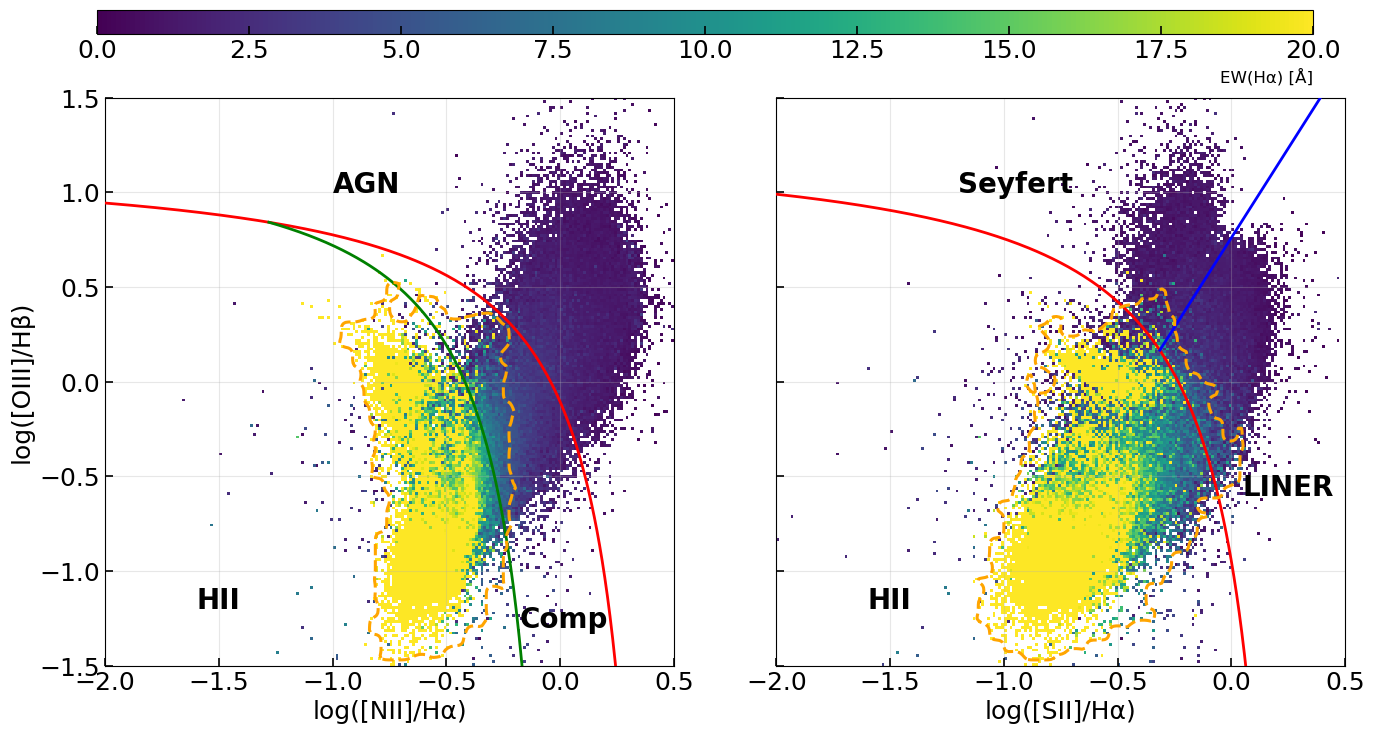


Successfully created combined NII/SII diagrams (flux+SFR+EW mask, color by EW(Hα))
Galaxies included: IC3392, NGC4064, NGC4192, NGC4293, NGC4298, NGC4330, NGC4383, NGC4396, NGC4419, NGC4457, NGC4501, NGC4522, NGC4694, NGC4698
Orange dashed contour marks boundary of EW(Hα) > 6 Å


In [2]:
# ------------------------------------------------------------------
# Combined Analysis: NII and SII diagrams - color by EW(Halpha)
# Collect all spaxels from all galaxies (no HII-only selection)
# Use only dust-corrected emission line fluxes; no O/H needed
# Apply SFR mask: keep spaxels with finite LOGSFR_SURFACE_DENSITY_HII,
#                  LOGSFR_SURFACE_DENSITY_NONHII, or LOGSFR_SURFACE_DENSITY_UNCLASSIFIED2
# ------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from pathlib import Path
from astropy.io import fits
from scipy.ndimage import binary_closing, binary_fill_holes, gaussian_filter, label


# BPT reference line functions (for drawing curves only, if desired)
def kewley01_N2(x):   # max-starburst
    return 0.61/(x-0.47) + 1.19


def kauff03_N2(x):    # empirical SF upper envelope
    return 0.61/(x-0.05) + 1.30


def kewley01_S2(x):
    return 0.72/(x-0.32) + 1.30


def kewley06_Sy_LIN(x):   # Seyfert/LINER division
    return 1.89*x + 0.76


# Error propagation for BPT ratios (log10 numerator/denominator)
def bpt_error_propagation(numerator, denominator, numerator_err, denominator_err):
    with np.errstate(divide='ignore', invalid='ignore'):
        log_ratio_err = 1/(np.log(10)) * np.sqrt((numerator_err / numerator)**2 + (denominator_err / denominator)**2)
        return log_ratio_err


def plot_closed_ew_boundary(ax, ew_grid, xedges, yedges, ew_threshold):
    finite_mask = np.isfinite(ew_grid)
    if not np.any(finite_mask):
        return

    gt_mask = finite_mask & (ew_grid > ew_threshold)
    if np.count_nonzero(gt_mask) < 10:
        return

    # Clean up isolated cells and fill small holes to form a closed boundary.
    cleaned = binary_closing(gt_mask, structure=np.ones((3, 3), dtype=bool), iterations=2)
    cleaned = binary_fill_holes(cleaned)

    labeled, n_regions = label(cleaned)
    if n_regions == 0:
        return

    region_sizes = np.bincount(labeled.ravel())
    region_sizes[0] = 0
    largest_region = labeled == np.argmax(region_sizes)

    smooth_region = gaussian_filter(largest_region.astype(float), sigma=1.2)
    xcenters = 0.5 * (xedges[:-1] + xedges[1:])
    ycenters = 0.5 * (yedges[:-1] + yedges[1:])

    ax.contour(
        xcenters,
        ycenters,
        smooth_region.T,
        levels=[0.5],
        colors='orange',
        linestyles='--',
        linewidths=2.2,
        zorder=11,
    )


# Create x arrays for the theoretical lines (optional overlay)
x_kewley_N2 = np.linspace(-2.0, 0.3, 200)
x_kauff_N2 = np.linspace((286-np.sqrt(2871561))/1100, 0.0, 200)
x_kewley_S2 = np.linspace(-2.0, 0.3, 200)
x_kewley06_S2 = np.linspace((159-np.sqrt(105081))/525, 0.5, 200)


# Get all galaxies from binning files
bins = sorted(Path('.').glob('*_SPATIAL_BINNING_maps_extended.fits'))
galaxies = [f.name.split('_')[0] for f in bins]

EW_FILE_SUFFIX = '_proxy_EW_maps.fits'
EW_HDU = 'PROXY_EWHA'
EW_CONTOUR = 6.0


# Collect all spaxels from all galaxies (no HII selection)
all_logN2 = []
all_logO3 = []
all_logS2 = []
all_ew = []

# Stats for SFR components
count_hii = 0
count_nonhii = 0
count_unclass = 0
count_union = 0
sum_check_total = 0
sum_check_ok = 0
sum_check_maxabs = []

# Stats for SF/NONSF/UNCLASSIFIED1 components
count_sf = 0
count_nonsf = 0
count_unclass1 = 0
count_union_sf = 0

# Error arrays for spaxel subsets
err_hii_logN2, err_hii_logS2, err_hii_logO3 = [], [], []
err_nonhii_logN2, err_nonhii_logS2, err_nonhii_logO3 = [], [], []
err_unclass_logN2, err_unclass_logS2, err_unclass_logO3 = [], [], []
err_hii_nonhii_logN2, err_hii_nonhii_logS2, err_hii_nonhii_logO3 = [], [], []
err_allclasses_logN2, err_allclasses_logS2, err_allclasses_logO3 = [], [], []

print('Collecting all spaxels from all galaxies (using corrected fluxes + EW, with SFR mask)...')
for gal in galaxies:
    gas_file = Path(f'{gal}_gas_BIN_maps_extended.fits')
    bin_file = Path(f'{gal}_SPATIAL_BINNING_maps_extended.fits')
    ew_file = Path(f'{gal}{EW_FILE_SUFFIX}')

    if gas_file.exists() and bin_file.exists() and ew_file.exists():
        with fits.open(gas_file) as h:
            # Load corrected emission line fluxes
            HB4861_FLUX_corr = h['HB4861_FLUX_CORR'].data
            HA6562_FLUX_corr = h['HA6562_FLUX_CORR'].data
            OIII5006_FLUX_corr = h['OIII5006_FLUX_CORR'].data
            NII6583_FLUX_corr = h['NII6583_FLUX_CORR'].data
            SII6716_FLUX_corr = h['SII6716_FLUX_CORR'].data
            SII6730_FLUX_corr = h['SII6730_FLUX_CORR'].data

            # Load corrected emission line flux errors
            HB4861_FLUX_ERR = h['HB4861_FLUX_ERR'].data
            HA6562_FLUX_ERR = h['HA6562_FLUX_ERR'].data
            OIII5006_FLUX_ERR = h['OIII5006_FLUX_ERR'].data
            NII6583_FLUX_ERR = h['NII6583_FLUX_ERR'].data
            SII6716_FLUX_ERR = h['SII6716_FLUX_ERR'].data
            SII6730_FLUX_ERR = h['SII6730_FLUX_ERR'].data

            # Load SFR surface density maps
            logSigmaSFR_HII = h['LOGSFR_SURFACE_DENSITY_HII'].data
            logSigmaSFR_NONHII = h['LOGSFR_SURFACE_DENSITY_NONHII'].data
            logSigmaSFR_UNCLASS = h['LOGSFR_SURFACE_DENSITY_UNCLASSIFIED2'].data
            logSigmaSFR_TOTAL = h['LOGSFR_SURFACE_DENSITY'].data

            # Load SF / NONSF / UNCLASSIFIED1 maps
            logSigmaSFR_SF = h['LOGSFR_SURFACE_DENSITY_SF'].data
            logSigmaSFR_NONSF = h['LOGSFR_SURFACE_DENSITY_NONSF'].data
            logSigmaSFR_UNCLASS1 = h['LOGSFR_SURFACE_DENSITY_UNCLASSIFIED1'].data

        with fits.open(ew_file) as h_ew:
            if EW_HDU not in h_ew:
                print(f'  {gal}: missing EW HDU {EW_HDU} in {ew_file.name}')
                continue
            ew_ha = h_ew[EW_HDU].data

        if ew_ha.shape != HA6562_FLUX_corr.shape:
            print(f'  {gal}: shape mismatch EW {ew_ha.shape} vs gas {HA6562_FLUX_corr.shape}')
            continue

        # SFR masks
        hii_mask = np.isfinite(logSigmaSFR_HII)
        nonhii_mask = np.isfinite(logSigmaSFR_NONHII)
        unclass_mask = np.isfinite(logSigmaSFR_UNCLASS)
        total_mask = np.isfinite(logSigmaSFR_TOTAL)
        union_mask = hii_mask | nonhii_mask | unclass_mask

        count_hii += np.sum(hii_mask)
        count_nonhii += np.sum(nonhii_mask)
        count_unclass += np.sum(unclass_mask)
        count_union += np.sum(union_mask)

        # SF / NONSF / UNCLASSIFIED1 masks
        sf_mask = np.isfinite(logSigmaSFR_SF)
        nonsf_mask = np.isfinite(logSigmaSFR_NONSF)
        unclass1_mask = np.isfinite(logSigmaSFR_UNCLASS1)
        union_sf_mask = sf_mask | nonsf_mask | unclass1_mask

        count_sf += np.sum(sf_mask)
        count_nonsf += np.sum(nonsf_mask)
        count_unclass1 += np.sum(unclass1_mask)
        count_union_sf += np.sum(union_sf_mask)

        # Check add-up consistency where all components and total are finite
        sum_mask = hii_mask & nonhii_mask & unclass_mask & total_mask
        if np.any(sum_mask):
            diff = logSigmaSFR_TOTAL[sum_mask] - (
                logSigmaSFR_HII[sum_mask] + logSigmaSFR_NONHII[sum_mask] + logSigmaSFR_UNCLASS[sum_mask]
            )
            sum_check_total += diff.size
            sum_check_ok += np.sum(np.isclose(diff, 0.0, atol=1e-6, rtol=0))
            sum_check_maxabs.append(np.nanmax(np.abs(diff)))

        # Valid where all corrected line fluxes are finite and positive
        flux_mask = (
            np.isfinite(HB4861_FLUX_corr) & (HB4861_FLUX_corr > 0) &
            np.isfinite(HA6562_FLUX_corr) & (HA6562_FLUX_corr > 0) &
            np.isfinite(OIII5006_FLUX_corr) & (OIII5006_FLUX_corr > 0) &
            np.isfinite(NII6583_FLUX_corr) & (NII6583_FLUX_corr > 0) &
            np.isfinite(SII6716_FLUX_corr) & (SII6716_FLUX_corr > 0) &
            np.isfinite(SII6730_FLUX_corr) & (SII6730_FLUX_corr > 0)
        )

        # SFR mask: keep spaxels where any class is finite
        sfr_mask = union_mask

        # EW mask
        ew_mask = np.isfinite(ew_ha) & (ew_ha > 0)

        # Combined mask for plotting
        valid_mask = flux_mask & sfr_mask & ew_mask
        n_pixels = np.sum(valid_mask)
        print(f'  {gal}: {n_pixels} valid spaxels (flux+SFR+EW mask)')

        HB_common = HB4861_FLUX_corr[valid_mask]
        HA_common = HA6562_FLUX_corr[valid_mask]
        OIII_common = OIII5006_FLUX_corr[valid_mask]
        NII_common = NII6583_FLUX_corr[valid_mask]
        SII6716_common = SII6716_FLUX_corr[valid_mask]
        SII6730_common = SII6730_FLUX_corr[valid_mask]
        EW_common = ew_ha[valid_mask]

        # Calculate line ratios for all valid spaxels
        logN2 = np.log10(NII_common / HA_common)
        logO3 = np.log10(OIII_common / HB_common)
        logS2 = np.log10((SII6716_common + SII6730_common) / HA_common)

        all_logN2.extend(logN2.flatten())
        all_logO3.extend(logO3.flatten())
        all_logS2.extend(logS2.flatten())
        all_ew.extend(EW_common.flatten())

        # Error propagation for spaxel subsets
        err_mask = (
            np.isfinite(HB4861_FLUX_ERR) & (HB4861_FLUX_ERR > 0) &
            np.isfinite(HA6562_FLUX_ERR) & (HA6562_FLUX_ERR > 0) &
            np.isfinite(OIII5006_FLUX_ERR) & (OIII5006_FLUX_ERR > 0) &
            np.isfinite(NII6583_FLUX_ERR) & (NII6583_FLUX_ERR > 0) &
            np.isfinite(SII6716_FLUX_ERR) & (SII6716_FLUX_ERR > 0) &
            np.isfinite(SII6730_FLUX_ERR) & (SII6730_FLUX_ERR > 0)
        )

        def collect_errs(sub_mask, out_N2, out_S2, out_O3):
            valid_err_mask = flux_mask & err_mask & ew_mask & sub_mask
            if np.any(valid_err_mask):
                hb = HB4861_FLUX_corr[valid_err_mask]
                ha = HA6562_FLUX_corr[valid_err_mask]
                o3 = OIII5006_FLUX_corr[valid_err_mask]
                n2 = NII6583_FLUX_corr[valid_err_mask]
                s2_1 = SII6716_FLUX_corr[valid_err_mask]
                s2_2 = SII6730_FLUX_corr[valid_err_mask]

                hb_err = HB4861_FLUX_ERR[valid_err_mask]
                ha_err = HA6562_FLUX_ERR[valid_err_mask]
                o3_err = OIII5006_FLUX_ERR[valid_err_mask]
                n2_err = NII6583_FLUX_ERR[valid_err_mask]
                s2_1_err = SII6716_FLUX_ERR[valid_err_mask]
                s2_2_err = SII6730_FLUX_ERR[valid_err_mask]

                s2 = s2_1 + s2_2
                s2_err = np.sqrt(s2_1_err**2 + s2_2_err**2)

                err_logN2 = bpt_error_propagation(n2, ha, n2_err, ha_err)
                err_logS2 = bpt_error_propagation(s2, ha, s2_err, ha_err)
                err_logO3 = bpt_error_propagation(o3, hb, o3_err, hb_err)

                out_N2.extend(err_logN2[np.isfinite(err_logN2)])
                out_S2.extend(err_logS2[np.isfinite(err_logS2)])
                out_O3.extend(err_logO3[np.isfinite(err_logO3)])

        collect_errs(hii_mask, err_hii_logN2, err_hii_logS2, err_hii_logO3)
        collect_errs(nonhii_mask, err_nonhii_logN2, err_nonhii_logS2, err_nonhii_logO3)
        collect_errs(unclass_mask, err_unclass_logN2, err_unclass_logS2, err_unclass_logO3)
        collect_errs(hii_mask | nonhii_mask, err_hii_nonhii_logN2, err_hii_nonhii_logS2, err_hii_nonhii_logO3)
        collect_errs(union_mask, err_allclasses_logN2, err_allclasses_logS2, err_allclasses_logO3)
    else:
        missing_parts = []
        if not gas_file.exists():
            missing_parts.append(gas_file.name)
        if not bin_file.exists():
            missing_parts.append(bin_file.name)
        if not ew_file.exists():
            missing_parts.append(ew_file.name)
        print(f"  {gal}: Missing files -> {', '.join(missing_parts)}")

# Convert to numpy arrays
all_logN2 = np.array(all_logN2)
all_logO3 = np.array(all_logO3)
all_logS2 = np.array(all_logS2)
all_ew = np.array(all_ew)

if len(all_logN2) == 0:
    raise RuntimeError('No valid spaxels found after applying flux+SFR+EW masks.')
if len(all_ew) != len(all_logN2):
    raise RuntimeError('EW array length mismatch with BPT arrays.')

# Report SFR component stats
print(f'\nTotal combined valid spaxels (flux+SFR+EW mask): {len(all_logN2)}')
if count_union > 0:
    print('\nSFR component counts (finite spaxels, all galaxies combined):')
    print(f'  HII: {count_hii} ({count_hii / count_union * 100:.3f}%)')
    print(f'  NONHII: {count_nonhii} ({count_nonhii / count_union * 100:.3f}%)')
    print(f'  UNCLASSIFIED2: {count_unclass} ({count_unclass / count_union * 100:.3f}%)')

if count_union > 0:
    print('\nSF component counts (finite spaxels, all galaxies combined):')
    print(f'  SF: {count_sf} ({count_sf / count_union * 100:.3f}%)')
    print(f'  NONSF: {count_nonsf} ({count_nonsf / count_union * 100:.3f}%)')
    print(f'  UNCLASSIFIED1: {count_unclass1} ({count_unclass1 / count_union * 100:.3f}%)')

if sum_check_total > 0:
    max_abs_diff = np.nanmax(sum_check_maxabs) if len(sum_check_maxabs) > 0 else np.nan
    print('\nCheck LOGSFR_SURFACE_DENSITY ≈ HII + NONHII + UNCLASSIFIED2 (finite spaxels):')
    print(f'  Passed: {sum_check_ok} / {sum_check_total} ({sum_check_ok / sum_check_total:.3f})')
    print(f'  Max |Δ|: {max_abs_diff:.3e}')

# Mean log-errors for requested subsets

def mean_or_nan(arr):
    return np.nanmean(arr) if len(arr) > 0 else np.nan

print('\nMean log-error (spaxel subsets):')
print(f'  HII only       - log([NII]/Hα): {mean_or_nan(err_hii_logN2):.4f}, log([SII]/Hα): {mean_or_nan(err_hii_logS2):.4f}, log([OIII]/Hβ): {mean_or_nan(err_hii_logO3):.4f}')
print(f'  NONHII only    - log([NII]/Hα): {mean_or_nan(err_nonhii_logN2):.4f}, log([SII]/Hα): {mean_or_nan(err_nonhii_logS2):.4f}, log([OIII]/Hβ): {mean_or_nan(err_nonhii_logO3):.4f}')
print(f'  UNCLASS only   - log([NII]/Hα): {mean_or_nan(err_unclass_logN2):.4f}, log([SII]/Hα): {mean_or_nan(err_unclass_logS2):.4f}, log([OIII]/Hβ): {mean_or_nan(err_unclass_logO3):.4f}')
print(f'  HII+NONHII     - log([NII]/Hα): {mean_or_nan(err_hii_nonhii_logN2):.4f}, log([SII]/Hα): {mean_or_nan(err_hii_nonhii_logS2):.4f}, log([OIII]/Hβ): {mean_or_nan(err_hii_nonhii_logO3):.4f}')
print(f'  HII+NONHII+UNC - log([NII]/Hα): {mean_or_nan(err_allclasses_logN2):.4f}, log([SII]/Hα): {mean_or_nan(err_allclasses_logS2):.4f}, log([OIII]/Hβ): {mean_or_nan(err_allclasses_logO3):.4f}')

# Create diagrams for all spaxels (2D EW color)
fig, axes = plt.subplots(1, 2, figsize=(16, 8), sharey=True)
plt.subplots_adjust(wspace=0.18, top=0.82)

# Binning and ranges
xlim = (-2.0, 0.5)
ylim = (-1.5, 1.5)
bins_2d = 200
min_count_per_bin = 3
vmin_ew = 0.0
vmax_ew = 20.0

# NII panel EW grid
hist_N2, xedges_N2, yedges_N2 = np.histogram2d(
    all_logN2, all_logO3, bins=bins_2d, range=[xlim, ylim]
)
sum_ew_N2, _, _ = np.histogram2d(
    all_logN2, all_logO3, bins=bins_2d, range=[xlim, ylim], weights=all_ew
)
mean_ew_N2 = np.divide(
    sum_ew_N2,
    hist_N2,
    out=np.full_like(sum_ew_N2, np.nan, dtype=float),
    where=hist_N2 > 0,
)
mean_ew_N2[hist_N2 < min_count_per_bin] = np.nan

# SII panel EW grid
hist_S2, xedges_S2, yedges_S2 = np.histogram2d(
    all_logS2, all_logO3, bins=bins_2d, range=[xlim, ylim]
)
sum_ew_S2, _, _ = np.histogram2d(
    all_logS2, all_logO3, bins=bins_2d, range=[xlim, ylim], weights=all_ew
)
mean_ew_S2 = np.divide(
    sum_ew_S2,
    hist_S2,
    out=np.full_like(sum_ew_S2, np.nan, dtype=float),
    where=hist_S2 > 0,
)
mean_ew_S2[hist_S2 < min_count_per_bin] = np.nan

# NII diagram
ax = axes[0]
img_N2 = ax.pcolormesh(
    xedges_N2,
    yedges_N2,
    np.ma.masked_invalid(mean_ew_N2.T),
    cmap='viridis',
    vmin=vmin_ew,
    vmax=vmax_ew,
    shading='auto',
)

# Optional: overlay BPT curves as reference only
ax.plot(x_kewley_N2, kewley01_N2(x_kewley_N2), 'r-', lw=2, label='Kewley+01', zorder=10)
ax.plot(x_kauff_N2, kauff03_N2(x_kauff_N2), 'g-', lw=2, label='Kauffmann+03', zorder=10)

plot_closed_ew_boundary(ax, mean_ew_N2, xedges_N2, yedges_N2, EW_CONTOUR)

ax.set_xlabel('log([NII]/Hα)', fontsize=18)
ax.set_ylabel('log([OIII]/Hβ)', fontsize=18)
ax.tick_params(axis='both', which='major', labelsize=18)
ax.set_xlim(xlim)
ax.set_ylim(ylim)
ax.text(-1.6, -1.2, 'HII', fontsize=20, fontweight='bold')
ax.text(-0.18, -1.3, 'Comp', fontsize=20, fontweight='bold')
ax.text(-1.0, 1.0, 'AGN', fontsize=20, fontweight='bold')
ax.grid(True, alpha=0.3)

# SII diagram
ax = axes[1]
img_S2 = ax.pcolormesh(
    xedges_S2,
    yedges_S2,
    np.ma.masked_invalid(mean_ew_S2.T),
    cmap='viridis',
    vmin=vmin_ew,
    vmax=vmax_ew,
    shading='auto',
)

ax.plot(x_kewley_S2, kewley01_S2(x_kewley_S2), 'r-', lw=2, label='Kewley+01', zorder=10)
ax.plot(x_kewley06_S2, kewley06_Sy_LIN(x_kewley06_S2), 'b-', lw=2, label='Kewley+06', zorder=10)

plot_closed_ew_boundary(ax, mean_ew_S2, xedges_S2, yedges_S2, EW_CONTOUR)

ax.set_xlabel('log([SII]/Hα)', fontsize=18)
ax.set_ylabel('')
ax.tick_params(axis='both', which='major', labelsize=18)
ax.tick_params(axis='y', labelleft=False)
ax.set_xlim(xlim)
ax.set_ylim(ylim)
ax.text(-1.6, -1.2, 'HII', fontsize=20, fontweight='bold')
ax.text(-1.2, 1.0, 'Seyfert', fontsize=20, fontweight='bold')
ax.text(0.05, -0.6, 'LINER', fontsize=20, fontweight='bold')
ax.grid(True, alpha=0.3)

# Shared colorbar (top, spanning both panels)
cax = fig.add_axes([0.12, 0.9, 0.76, 0.03])
cbar = fig.colorbar(img_N2, cax=cax, orientation='horizontal')
cbar.set_label('EW(Hα) [Å]', fontsize=12, loc='right')
cbar.ax.tick_params(labelsize=18)

# Save figures
output_dir = Path('Plot_Paper_1_referee')
output_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(output_dir / 'Combined_BPT_diagrams_by_EW_HII_NONHII.png', dpi=600, bbox_inches='tight')
fig.savefig(output_dir / 'Combined_BPT_diagrams_by_EW_HII_NONHII.pdf', bbox_inches='tight')
plt.show()

print('\nSuccessfully created combined NII/SII diagrams (flux+SFR+EW mask, color by EW(Hα))')
print('Galaxies included: ' + ', '.join(galaxies))
print(f'Orange dashed contour marks boundary of EW(Hα) > {EW_CONTOUR:g} Å')

Loaded published integrated properties for target galaxies:
  IC3392: logM*=9.810 +/- 0.060 [Villanueva+2022]; logSFR=-1.300 +/- 0.200 [Leroy+2021]
  NGC4064: logM*=10.010 +/- 0.090 [Villanueva+2022]; logSFR=-1.070 +/- 0.200 [Leroy+2021]
  NGC4192: logM*=10.780 +/- 0.100 [Leroy+2021]; logSFR=0.130 +/- 0.200 [Leroy+2021]
  NGC4293: logM*=10.510 +/- 0.070 [Villanueva+2022]; logSFR=-0.270 +/- 0.200 [Leroy+2021]
  NGC4298: logM*=10.020 +/- 0.070 [Villanueva+2022]; logSFR=-0.260 +/- 0.200 [Leroy+2021]
  NGC4330: logM*=9.600 [local mass log]; logSFR=-0.810 [local sfr log]
  NGC4383: logM*=9.580 +/- 0.070 [Villanueva+2022]; logSFR=0.010 +/- 0.200 [Leroy+2021]
  NGC4396: logM*=9.360 +/- 0.100 [Leroy+2021]; logSFR=-0.670 +/- 0.200 [Leroy+2021]
  NGC4419: logM*=10.230 +/- 0.080 [Villanueva+2022]; logSFR=-0.120 +/- 0.200 [Leroy+2021]
  NGC4457: logM*=10.360 +/- 0.080 [Villanueva+2022]; logSFR=-0.490 +/- 0.200 [Leroy+2021]
  NGC4501: logM*=10.990 +/- 0.080 [Villanueva+2022]; logSFR=0.430 +/- 0.200

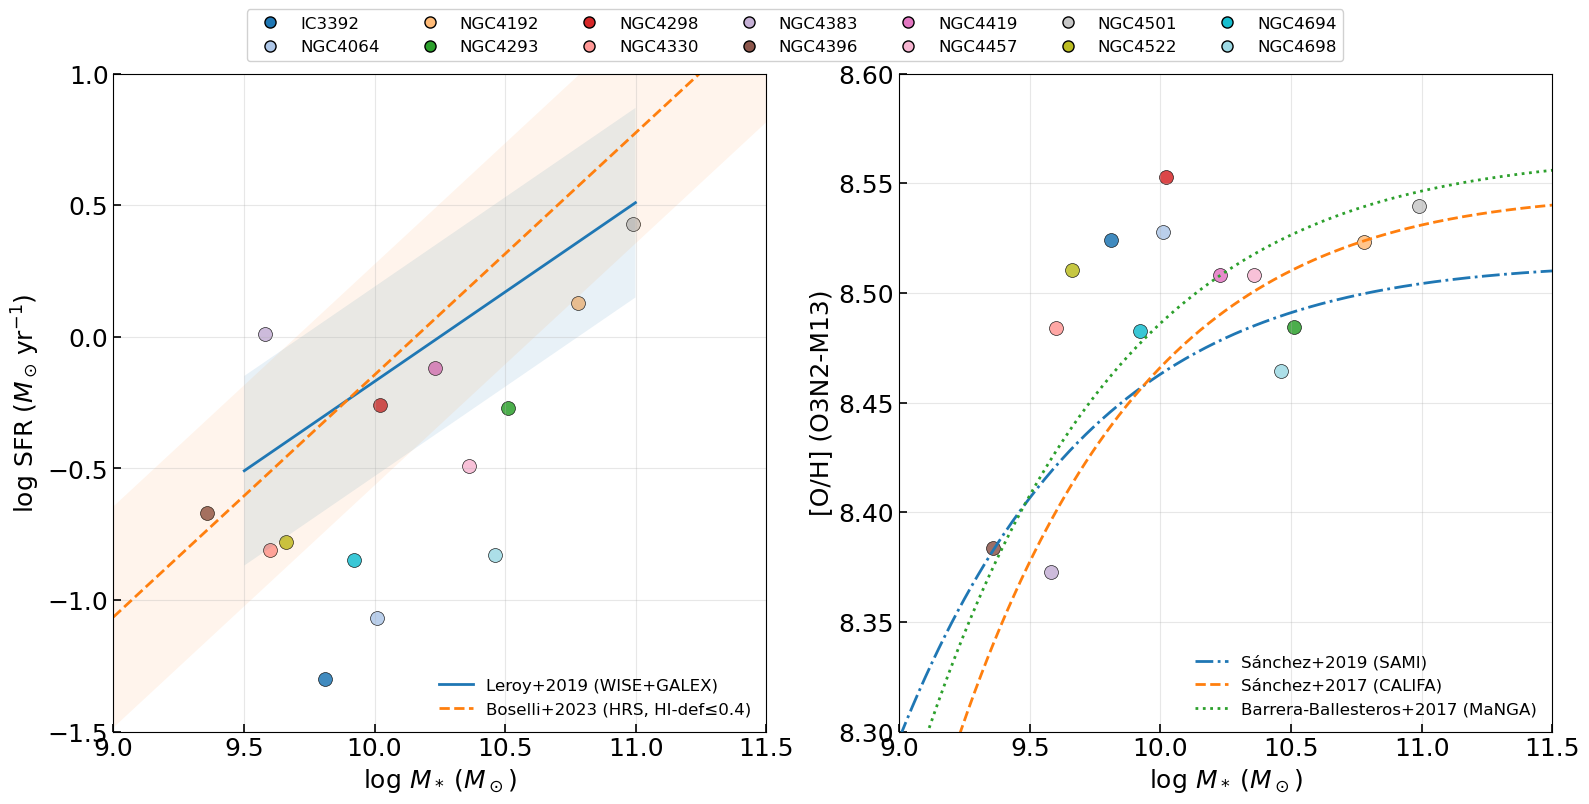

Subplot 1 (Integrated SFMS): Plotted 14 galaxies with valid total mass and SFR data
Subplot 2 (Integrated MZR, O3N2-M13 total region): Plotted 14 galaxies with valid total mass and total-region metallicity data


In [3]:
# ------------------------------------------------------------------
# Combined Plot: Integrated SFMS + Integrated MZR (O3N2-M13 total region)
# ------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from pathlib import Path
import re


# ------------------------------------------------------------------
# Published integrated properties used in this figure:
#   Stellar mass: Villanueva+2022 (Table 1; machinery table in local txt file)
#   SFR: Leroy+2021 (Table 4; fixed-width table in local txt file)
# Values are read from local table files at runtime (not hardcoded).
# ------------------------------------------------------------------

GALAXIES = [
    'IC3392',
    'NGC4064',
    'NGC4192',
    'NGC4293',
    'NGC4298',
    'NGC4330',
    'NGC4383',
    'NGC4396',
    'NGC4419',
    'NGC4457',
    'NGC4501',
    'NGC4522',
    'NGC4694',
    'NGC4698',
]

VILLANUEVA_TABLE_PATH = Path('Villanueva2022Table1.txt')
LEROY_TABLE_PATH = Path('Leroy2021Table4.txt')


def normalize_galaxy_name(name):
    return re.sub(r'\s+', '', name).upper()


def parse_float(token):
    token = token.strip()
    if token == '':
        return None
    try:
        return float(token)
    except ValueError:
        return None


def load_villanueva2022_stellar_mass(table_path):
    """Load logM* (and its uncertainty) from Villanueva+2022 Table 1 txt export."""
    if not table_path.exists():
        raise FileNotFoundError(f'Missing table file: {table_path}')

    logmstar = {}
    e_logmstar = {}

    with open(table_path, 'r') as f:
        for raw_line in f:
            line = raw_line.strip()
            if not re.match(r'^(IC|NGC)\s+\d+', line):
                continue

            cols = [c.strip() for c in re.split(r'\t+', line)]
            if len(cols) < 4:
                continue

            name = normalize_galaxy_name(cols[0])
            m = re.search(r'([-+]?\d*\.?\d+)\s*\+or-\s*([-+]?\d*\.?\d+)', cols[3])
            if m is None:
                continue

            logmstar[name] = float(m.group(1))
            e_logmstar[name] = float(m.group(2))

    return logmstar, e_logmstar


def load_leroy2021_properties(table_path):
    """Load logM* and logSFR (and uncertainties) from Leroy+2021 Table 4 fixed-width txt."""
    if not table_path.exists():
        raise FileNotFoundError(f'Missing table file: {table_path}')

    logmstar = {}
    e_logmstar = {}
    logsfr = {}
    e_logsfr = {}

    with open(table_path, 'r') as f:
        for raw_line in f:
            if not raw_line[:7].strip().isdigit():
                continue

            ngc = raw_line[8:17].strip()
            ic = raw_line[29:36].strip()
            if ngc:
                name = normalize_galaxy_name(ngc)
            elif ic:
                name = normalize_galaxy_name(ic)
            else:
                continue

            val_logmstar = parse_float(raw_line[48:53])
            if val_logmstar is not None:
                logmstar[name] = val_logmstar
                e_logmstar[name] = parse_float(raw_line[54:58])

            val_logsfr = parse_float(raw_line[73:78])
            if val_logsfr is None:
                continue

            logsfr[name] = val_logsfr
            e_logsfr[name] = parse_float(raw_line[79:83])

    return logmstar, e_logmstar, logsfr, e_logsfr


VILLANUEVA_LOGMSTAR, VILLANUEVA_E_LOGMSTAR = load_villanueva2022_stellar_mass(VILLANUEVA_TABLE_PATH)
LEROY_LOGMSTAR, LEROY_E_LOGMSTAR, LEROY_LOGSFR, LEROY_E_LOGSFR = load_leroy2021_properties(LEROY_TABLE_PATH)


def extract_total_sfr_from_log(galaxy_name):
    """Extract fallback log10(SFR/Msun yr^-1) from local sfr_logs/<gal>.log."""
    log_file = Path(f'sfr_logs/{galaxy_name}.log')
    if not log_file.exists():
        return None

    try:
        with open(log_file, 'r') as f:
            content = f.read()
        pattern = r'Total Halpha SFR from SF region:.*?in log10 scale:\s*([\d.-]+)\s*log\(M☉/yr\)'
        match = re.search(pattern, content)
        return float(match.group(1)) if match else None
    except Exception as e:
        print(f"Error reading fallback SFR log for {galaxy_name}: {e}")
        return None


def extract_total_stellar_mass_from_log(galaxy_name):
    """Extract fallback log10(M*/Msun) from local mass_logs/<gal>.log."""
    log_file = Path(f'mass_logs/{galaxy_name}.log')
    if not log_file.exists():
        return None

    try:
        with open(log_file, 'r') as f:
            content = f.read()
        pattern = r'Total stellar mass \(R\)\s*:\s*([\d.-]+)\s*log10\(M☉\)'
        match = re.search(pattern, content)
        return float(match.group(1)) if match else None
    except Exception as e:
        print(f"Error reading fallback mass log for {galaxy_name}: {e}")
        return None

print('Loaded published integrated properties for target galaxies:')
for gal in GALAXIES:
    m_v = VILLANUEVA_LOGMSTAR.get(gal)
    em_v = VILLANUEVA_E_LOGMSTAR.get(gal)
    m_l = LEROY_LOGMSTAR.get(gal)
    em_l = LEROY_E_LOGMSTAR.get(gal)
    m_log = extract_total_stellar_mass_from_log(gal)

    s_l = LEROY_LOGSFR.get(gal)
    es_l = LEROY_E_LOGSFR.get(gal)
    s_log = extract_total_sfr_from_log(gal)

    if m_v is not None:
        m, em, m_source = m_v, em_v, 'Villanueva+2022'
    elif m_l is not None:
        m, em, m_source = m_l, em_l, 'Leroy+2021'
    elif m_log is not None:
        m, em, m_source = m_log, None, 'local mass log'
    else:
        m, em, m_source = None, None, 'MISSING'

    if s_l is not None:
        s, es, s_source = s_l, es_l, 'Leroy+2021'
    elif s_log is not None:
        s, es, s_source = s_log, None, 'local sfr log'
    else:
        s, es, s_source = None, None, 'MISSING'

    if m is None:
        m_str = 'MISSING'
    elif em is None:
        m_str = f'{m:.3f} [{m_source}]'
    else:
        m_str = f'{m:.3f} +/- {em:.3f} [{m_source}]'

    if s is None:
        s_str = 'MISSING'
    elif es is None:
        s_str = f'{s:.3f} [{s_source}]'
    else:
        s_str = f'{s:.3f} +/- {es:.3f} [{s_source}]'

    print(f'  {gal}: logM*={m_str}; logSFR={s_str}')


def get_integrated_stellar_mass(galaxy_name):
    """Return log10(M*/Msun): Villanueva+2022 -> Leroy+2021 -> local mass log."""
    val = VILLANUEVA_LOGMSTAR.get(galaxy_name)
    if val is not None:
        return val
    val = LEROY_LOGMSTAR.get(galaxy_name)
    if val is not None:
        return val
    return extract_total_stellar_mass_from_log(galaxy_name)


def get_integrated_sfr(galaxy_name):
    """Return log10(SFR/Msun yr^-1): Leroy+2021 first, then local log fallback."""
    val = LEROY_LOGSFR.get(galaxy_name)
    if val is not None:
        return val
    return extract_total_sfr_from_log(galaxy_name)


def extract_total_o3n2_m13_total_metallicity(galaxy_name):
    """Extract total O3N2-M13 metallicity from total region in SFR log. Returns [O/H] or None."""
    log_file = Path(f'sfr_logs/{galaxy_name}.log')
    if not log_file.exists():
        return None

    try:
        with open(log_file, 'r') as f:
            content = f.read()
        pattern = r'\[O/H\] O3N2-M13: Total metallicity in total region:\s*([\d.-]+)'
        match = re.search(pattern, content)
        return float(match.group(1)) if match else None
    except Exception as e:
        print(f"Error reading O3N2-M13 total metallicity log for {galaxy_name}: {e}")
        return None


def sfms_leroy2019(logM, valid=(9.5, 11.0)):
    """Leroy+2019 eq.19 converted to log SFR: logSFR = 0.68*logM - 6.97."""
    logM = np.asarray(logM)
    y = 0.68 * logM - 6.97
    y = np.where((logM < valid[0]) | (logM > valid[1]), np.nan, y)
    return y


def sfms_boselli2023(logM, slope=0.92, intercept=-1.57, x_pivot=8.451):
    """Boselli+2023 (HRS, HI-def ≤ 0.4): y = slope * (logM - x_pivot) + intercept."""
    logM = np.asarray(logM)
    return slope * (logM - x_pivot) + intercept


def mzr_sanchez2019(logM, a=8.51, b=0.007, c=3.5):
    """Sánchez+2019 SAMI relation (O3N2-M13 calibration)."""
    logM = np.asarray(logM, dtype=float)
    x = logM - 8.0
    t = x - c
    return a + b * t * np.exp(-t)


def mzr_sanchez2017(logM, a=8.54, b=0.011, c=3.5):
    """Sánchez+2017 CALIFA relation (O3N2-M13 calibration)."""
    logM = np.asarray(logM, dtype=float)
    x = logM - 8.0
    t = x - c
    return a + b * t * np.exp(-t)


def mzr_barrera_ballesteros2017_m13(logM, a=8.56, b=0.005, c=4.0):
    """Barrera-Ballesteros+2017 MaNGA characteristic-abundance relation (O3N2-M13)."""
    logM = np.asarray(logM, dtype=float)
    x = logM - 8.0
    t = x - c
    return a + b * t * np.exp(-t)


# def mzr_alvarez_hurtado2022_m13_exp(logM, a, b, c=3.5):
#     """
#     Alvarez-Hurtado+2022 eCALIFA exponential-form MZR:
#         y = a + b * (x8 - c) * exp(-(x8 - c))
#     where x8 = logM - 8
#     """
#     logM = np.asarray(logM, dtype=float)
#     x8 = logM - 8.0
#     t = x8 - c
#     return a + b * t * np.exp(-t)


# Coefficients used for plotting the AH22 exponential-form relation
AH22_M13_A = 8.72
AH22_M13_B = 0.005

# ------------------------------------------------------------------
# Build integrated-data containers
# ------------------------------------------------------------------
sfms_masses = []
sfms_sfrs = []
sfms_names = []

mzr_masses = []
mzr_oh_total = []
mzr_names = []

for gal in GALAXIES:
    mass = get_integrated_stellar_mass(gal)
    sfr = get_integrated_sfr(gal)
    oh_total = extract_total_o3n2_m13_total_metallicity(gal)

    if mass is not None and sfr is not None:
        sfms_masses.append(mass)
        sfms_sfrs.append(sfr)
        sfms_names.append(gal)

    if mass is not None and oh_total is not None:
        mzr_masses.append(mass)
        mzr_oh_total.append(oh_total)
        mzr_names.append(gal)

sfms_masses = np.array(sfms_masses)
sfms_sfrs = np.array(sfms_sfrs)
mzr_masses = np.array(mzr_masses)
mzr_oh_total = np.array(mzr_oh_total)
galaxies = list(GALAXIES)

# Consistent colors across both panels
if len(galaxies) > 0:
    galaxy_colors = plt.cm.tab20(np.linspace(0, 1, len(galaxies)))
    galaxy_color_dict = dict(zip(galaxies, galaxy_colors))
else:
    galaxy_color_dict = {}

# Build figure with only two integrated subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# ------------------------------------------------------------------
# SUBPLOT 1: Integrated SFMS
# ------------------------------------------------------------------
for mass, sfr, gal in zip(sfms_masses, sfms_sfrs, sfms_names):
    color = galaxy_color_dict.get(gal, 'tab:blue')
    ax1.scatter(mass, sfr, s=100, c=[color], alpha=0.85, edgecolors='black', linewidth=0.5)

x_sfms = np.linspace(9.0, 11.5, 400)
y_l19 = sfms_leroy2019(x_sfms)
y_b23 = sfms_boselli2023(x_sfms)
ax1.plot(x_sfms, y_l19, lw=2, ls='-', label='Leroy+2019 (WISE+GALEX)')
ax1.fill_between(x_sfms, y_l19 - 0.36, y_l19 + 0.36, alpha=0.10, linewidth=0)
ax1.plot(x_sfms, y_b23, lw=2, ls='--', label='Boselli+2023 (HRS, HI-def≤0.4)')
ax1.fill_between(x_sfms, y_b23 - 0.42, y_b23 + 0.42, alpha=0.08, linewidth=0)

ax1.set_xlabel(r'$\log\,M_* \; (M_\odot)$')
ax1.set_ylabel(r'$\log\,\mathrm{SFR} \; (M_\odot\,\mathrm{yr}^{-1})$')
# ax1.set_title('Integrated Star-Forming Main Sequence')
ax1.set_xlim(9.0, 11.5)
ax1.set_ylim(-1.5, 1.0)
ax1.grid(True, alpha=0.3)
ax1.legend(frameon=False, loc='lower right')

# ------------------------------------------------------------------
# SUBPLOT 2: Integrated MZR (O3N2-M13 total region)
# ------------------------------------------------------------------
for mass, oh_total, gal in zip(mzr_masses, mzr_oh_total, mzr_names):
    color = galaxy_color_dict.get(gal, 'tab:orange')
    ax2.scatter(mass, oh_total, s=100, c=[color], alpha=0.85, edgecolors='black', linewidth=0.5)

x_mzr = np.linspace(9.0, 11.5, 400)
ax2.plot(x_mzr, mzr_sanchez2019(x_mzr), lw=2, ls='-.', label='Sánchez+2019 (SAMI)')
ax2.plot(x_mzr, mzr_sanchez2017(x_mzr), lw=2, ls='--', label='Sánchez+2017 (CALIFA)')
ax2.plot(x_mzr, mzr_barrera_ballesteros2017_m13(x_mzr), lw=2, ls=':', label='Barrera-Ballesteros+2017 (MaNGA)')
# ax2.plot(
#     x_mzr,
#     mzr_alvarez_hurtado2022_m13_exp(x_mzr, AH22_M13_A, AH22_M13_B),
#     lw=2,
#     ls='-',
#     color='black',
#     alpha=0.9,
#     label='Alvarez-Hurtado+2022 (eCALIFA)',
# )

ax2.set_xlabel(r'$\log\,M_* \; (M_\odot)$')
ax2.set_ylabel(r'[O/H] (O3N2-M13)')
# ax2.set_title('Integrated Mass-Metallicity Relation (O3N2-M13 total region)')
ax2.set_xlim(9.0, 11.5)
ax2.set_ylim(8.3, 8.6)
ax2.grid(True, alpha=0.3)
ax2.legend(frameon=False, loc='lower right')

# Shared galaxy legend for both subplots (replaces per-point text annotations)
plotted_galaxies = [gal for gal in galaxies if (gal in sfms_names or gal in mzr_names)]
legend_handles = [
    Line2D(
        [0], [0], marker='o', color='none', linestyle='None', markersize=8,
        markerfacecolor=galaxy_color_dict.get(gal, 'gray'), markeredgecolor='black'
    )
    for gal in plotted_galaxies
]
if legend_handles:
    fig.legend(
        legend_handles,
        plotted_galaxies,
        loc='upper center',
        bbox_to_anchor=(0.5, 1.01),
        ncol=min(len(plotted_galaxies), 7),
        framealpha=0.9,
    )

plt.tight_layout(rect=[0, 0, 1, 0.95])

output_dir = Path('Plot_Paper_1_referee')
output_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(output_dir / 'Integrated_SFMS_MZR_TOTAL.png', dpi=600, bbox_inches='tight')
fig.savefig(output_dir / 'Integrated_SFMS_MZR_TOTAL.pdf', bbox_inches='tight')
plt.show()

print(f"Subplot 1 (Integrated SFMS): Plotted {len(sfms_names)} galaxies with valid total mass and SFR data")
print(f"Subplot 2 (Integrated MZR, O3N2-M13 total region): Plotted {len(mzr_names)} galaxies with valid total mass and total-region metallicity data")

Curti+2020 FMR residuals (O3N2-C20, total region) for the 14 galaxies
Galaxy     logM*    logSFR    Z_obs    Z_pred   Delta(obs-pred)
IC3392     9.810    -1.300    8.739    8.771     -0.032
NGC4064   10.010    -1.070    8.742    8.774     -0.031
NGC4192   10.780     0.130    8.738    8.776     -0.037
NGC4293   10.510    -0.270    8.701    8.775     -0.073
NGC4298   10.020    -0.260    8.766    8.743     +0.023
NGC4330    9.600    -0.810    8.701    8.725     -0.024
NGC4383    9.580     0.010    8.587    8.608     -0.022
NGC4396    9.360    -0.670    8.599    8.653     -0.054
NGC4419   10.230    -0.120    8.724    8.757     -0.033
NGC4457   10.360    -0.490    8.724    8.774     -0.050
NGC4501   10.990     0.430    8.753    8.776     -0.023
NGC4522    9.660    -0.780    8.726    8.732     -0.006
NGC4694    9.920    -0.850    8.699    8.765     -0.065
NGC4698   10.460    -0.830    8.681    8.778     -0.096

N                = 14
Mean delta_Z     = -0.037 dex
Median delta_Z   = -0.033 dex

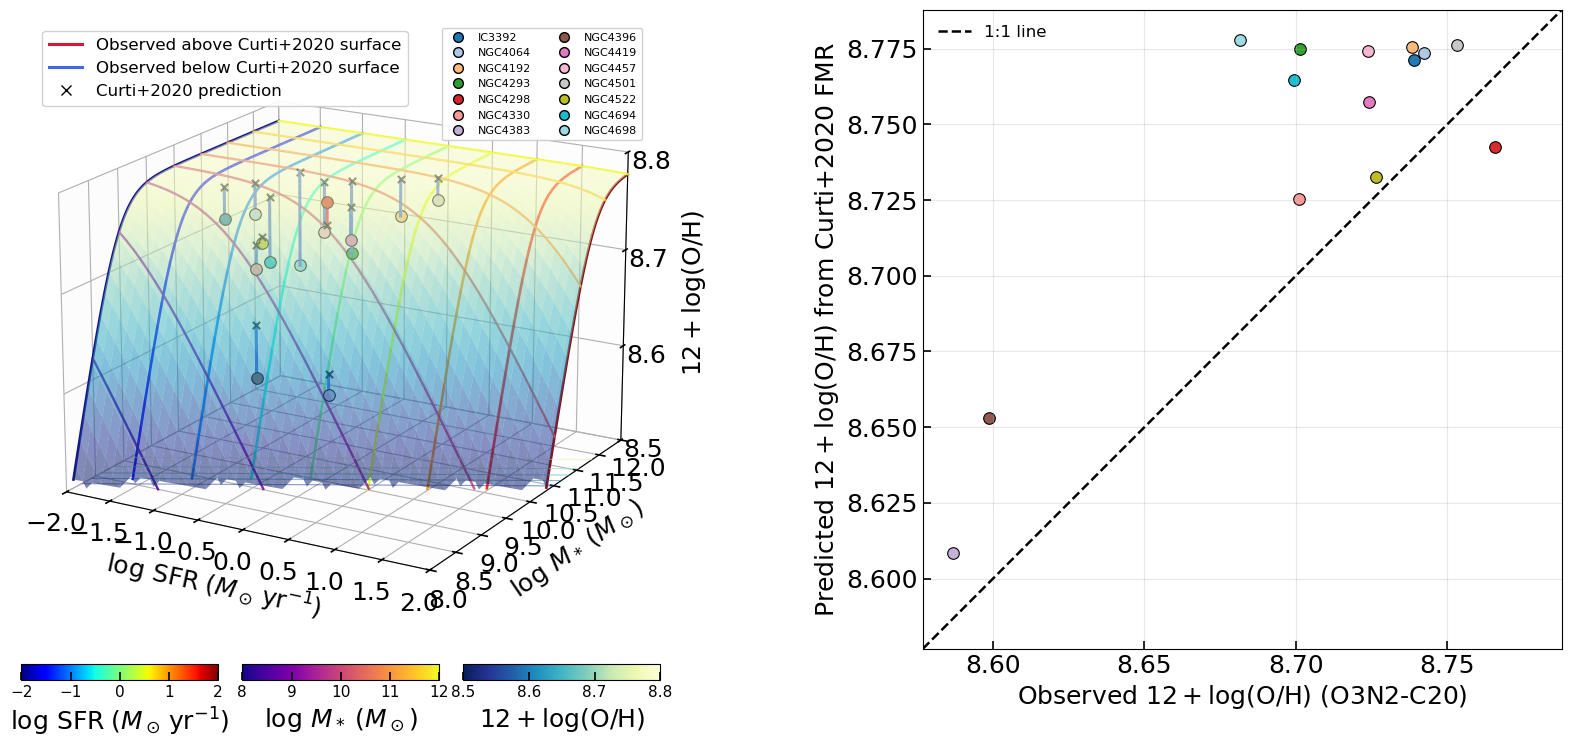

In [4]:
# ================================================================
# 3D Curti+2020 FMR surface + MAUVE/VERTICO 14 galaxies
# with bottom SFR, M*, and metallicity colorbars
# ================================================================

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import re
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from matplotlib import cm
from matplotlib.lines import Line2D
from matplotlib.colors import Normalize

# ------------------------------------------------
# Local integrated-property loaders (cell runs standalone)
# ------------------------------------------------
VILLANUEVA_TABLE_PATH = Path("Villanueva2022Table1.txt")
LEROY_TABLE_PATH = Path("Leroy2021Table4.txt")


def normalize_galaxy_name(name):
    return re.sub(r"\s+", "", name).upper()


def parse_float(token):
    token = token.strip()
    if token == "":
        return None
    try:
        return float(token)
    except ValueError:
        return None


def load_villanueva2022_stellar_mass(table_path):
    """Load logM* from Villanueva+2022 table if available."""
    logmstar = {}
    if not table_path.exists():
        return logmstar

    with open(table_path, "r") as f:
        for raw_line in f:
            line = raw_line.strip()
            if not re.match(r"^(IC|NGC)\s+\d+", line):
                continue

            cols = [c.strip() for c in re.split(r"\t+", line)]
            if len(cols) < 4:
                continue

            name = normalize_galaxy_name(cols[0])
            m = re.search(r"([-+]?\d*\.?\d+)\s*\+or-\s*([-+]?\d*\.?\d+)", cols[3])
            if m is None:
                continue

            logmstar[name] = float(m.group(1))

    return logmstar


def load_leroy2021_properties(table_path):
    """Load logM* and logSFR from Leroy+2021 table if available."""
    logmstar = {}
    logsfr = {}
    if not table_path.exists():
        return logmstar, logsfr

    with open(table_path, "r") as f:
        for raw_line in f:
            if not raw_line[:7].strip().isdigit():
                continue

            ngc = raw_line[8:17].strip()
            ic = raw_line[29:36].strip()
            if ngc:
                name = normalize_galaxy_name(ngc)
            elif ic:
                name = normalize_galaxy_name(ic)
            else:
                continue

            val_logmstar = parse_float(raw_line[48:53])
            if val_logmstar is not None:
                logmstar[name] = val_logmstar

            val_logsfr = parse_float(raw_line[73:78])
            if val_logsfr is not None:
                logsfr[name] = val_logsfr

    return logmstar, logsfr


def extract_total_sfr_from_log(galaxy_name):
    """Extract fallback log10(SFR/Msun yr^-1) from local sfr_logs/<gal>.log."""
    log_file = Path(f"sfr_logs/{galaxy_name}.log")
    if not log_file.exists():
        return None

    try:
        with open(log_file, "r") as f:
            content = f.read()
        pattern = r"Total Halpha SFR from SF region:.*?in log10 scale:\s*([\d.-]+)"
        match = re.search(pattern, content)
        return float(match.group(1)) if match else None
    except Exception as e:
        print(f"Error reading fallback SFR log for {galaxy_name}: {e}")
        return None


def extract_total_stellar_mass_from_log(galaxy_name):
    """Extract fallback log10(M*/Msun) from local mass_logs/<gal>.log."""
    log_file = Path(f"mass_logs/{galaxy_name}.log")
    if not log_file.exists():
        return None

    try:
        with open(log_file, "r") as f:
            content = f.read()
        pattern = r"Total stellar mass \(R\)\s*:\s*([\d.-]+)"
        match = re.search(pattern, content)
        return float(match.group(1)) if match else None
    except Exception as e:
        print(f"Error reading fallback mass log for {galaxy_name}: {e}")
        return None


VILLANUEVA_LOGMSTAR = load_villanueva2022_stellar_mass(VILLANUEVA_TABLE_PATH)
LEROY_LOGMSTAR, LEROY_LOGSFR = load_leroy2021_properties(LEROY_TABLE_PATH)


def get_integrated_stellar_mass(galaxy_name):
    """Return log10(M*/Msun): Villanueva+2022 -> Leroy+2021 -> local mass log."""
    val = VILLANUEVA_LOGMSTAR.get(galaxy_name)
    if val is not None:
        return val
    val = LEROY_LOGMSTAR.get(galaxy_name)
    if val is not None:
        return val
    return extract_total_stellar_mass_from_log(galaxy_name)


def get_integrated_sfr(galaxy_name):
    """Return log10(SFR/Msun yr^-1): Leroy+2021 first, then local log fallback."""
    val = LEROY_LOGSFR.get(galaxy_name)
    if val is not None:
        return val
    return extract_total_sfr_from_log(galaxy_name)


def extract_total_o3n2_c20_total_metallicity(galaxy_name):
    """Extract total O3N2-C20 metallicity from total region in SFR log. Returns [O/H] or None."""
    log_file = Path(f"sfr_logs/{galaxy_name}.log")
    if not log_file.exists():
        return None

    try:
        with open(log_file, "r") as f:
            content = f.read()
        pattern = r"\[O/H\] O3N2-C20: Total metallicity in total region:\s*([+-]?(?:\d+\.?\d*|\.\d+|nan))"
        match = re.search(pattern, content)
        if not match:
            return None

        value = float(match.group(1))
        return value if np.isfinite(value) else None
    except Exception as e:
        print(f"Error reading O3N2-C20 total metallicity log for {galaxy_name}: {e}")
        return None


# ------------------------------------------------
# Target galaxies
# ------------------------------------------------
GALAXIES = [
    "IC3392",
    "NGC4064",
    "NGC4192",
    "NGC4293",
    "NGC4298",
    "NGC4330",
    "NGC4383",
    "NGC4396",
    "NGC4419",
    "NGC4457",
    "NGC4501",
    "NGC4522",
    "NGC4694",
    "NGC4698",
]


# ------------------------------------------------
# Curti+2020 total-SFR FMR parameters
# ------------------------------------------------
CURTI_Z0 = 8.779
CURTI_M0 = 10.11
CURTI_M1 = 0.56
CURTI_GAMMA = 0.31
CURTI_BETA = 2.1


def curti2020_fmr_total_sfr(
    logMstar,
    logSFR,
    Z0=CURTI_Z0,
    m0=CURTI_M0,
    m1=CURTI_M1,
    gamma=CURTI_GAMMA,
    beta=CURTI_BETA,
):
    """
    Curti+2020 FMR surface for total SFR.
    Input:
        logMstar = log10(M*/Msun)
        logSFR   = log10(SFR/[Msun/yr])
    Returns:
        predicted 12+log(O/H)
    """
    logMstar = np.asarray(logMstar, dtype=float)
    logSFR = np.asarray(logSFR, dtype=float)

    logM0_sfr = m0 + m1 * logSFR
    term = 10.0 ** (-beta * (logMstar - logM0_sfr))
    return Z0 - (gamma / beta) * np.log10(1.0 + term)


# ------------------------------------------------
# Gather galaxy data
# ------------------------------------------------
rows = []
for gal in GALAXIES:
    logM = get_integrated_stellar_mass(gal)
    logSFR = get_integrated_sfr(gal)
    Z_obs = extract_total_o3n2_c20_total_metallicity(gal)

    if logM is None or logSFR is None or Z_obs is None:
        print(f"Skipping {gal}: missing logM, logSFR, or metallicity")
        continue

    Z_pred = curti2020_fmr_total_sfr(logM, logSFR)
    deltaZ = Z_obs - Z_pred

    rows.append(
        {
            "gal": gal,
            "logM": float(logM),
            "logSFR": float(logSFR),
            "Z_obs": float(Z_obs),
            "Z_pred": float(Z_pred),
            "deltaZ": float(deltaZ),
        }
    )

if len(rows) == 0:
    raise RuntimeError("No valid galaxy entries found.")

gal_names = [r["gal"] for r in rows]
logM_arr = np.array([r["logM"] for r in rows])
logSFR_arr = np.array([r["logSFR"] for r in rows])
Z_obs_arr = np.array([r["Z_obs"] for r in rows])
Z_pred_arr = np.array([r["Z_pred"] for r in rows])
delta_arr = np.array([r["deltaZ"] for r in rows])


# ------------------------------------------------
# Print summary
# ------------------------------------------------
print("Curti+2020 FMR residuals (O3N2-C20, total region) for the 14 galaxies")
print("Galaxy     logM*    logSFR    Z_obs    Z_pred   Delta(obs-pred)")
for r in rows:
    print(
        f"{r['gal']:8s}  {r['logM']:6.3f}   {r['logSFR']:7.3f}   "
        f"{r['Z_obs']:6.3f}   {r['Z_pred']:6.3f}    {r['deltaZ']:+7.3f}"
    )

print()
print(f"N                = {len(rows)}")
print(f"Mean delta_Z     = {np.mean(delta_arr):+.3f} dex")
print(f"Median delta_Z   = {np.median(delta_arr):+.3f} dex")
print(f"RMS delta_Z      = {np.sqrt(np.mean(delta_arr**2)):.3f} dex")
print(f"Std(delta_Z)     = {np.std(delta_arr, ddof=1):.3f} dex")


# ------------------------------------------------
# Surface grid
# ------------------------------------------------
x_min = min(8.0, np.floor(logM_arr.min() * 10) / 10 - 0.3)
x_max = max(12.0, np.ceil(logM_arr.max() * 10) / 10 + 0.3)
y_min = min(-2.0, np.floor(logSFR_arr.min() * 10) / 10 - 0.3)
y_max = max(2.0, np.ceil(logSFR_arr.max() * 10) / 10 + 0.3)

x_grid = np.linspace(x_min, x_max, 100)
y_grid = np.linspace(y_min, y_max, 100)
XX, YY = np.meshgrid(x_grid, y_grid)
ZZ = curti2020_fmr_total_sfr(XX, YY)

# Requested display range for metallicity axis
z_floor = 8.5
z_top = 8.8

# Mask out-of-bounds Z values to prevent spilling over the visual limits
ZZ_plot = np.where((ZZ >= z_floor) & (ZZ <= z_top), ZZ, np.nan)

# Colormap normalizations for colorbars
sfr_norm = Normalize(vmin=y_min, vmax=y_max)
mstar_norm = Normalize(vmin=x_min, vmax=x_max)
surface_norm = Normalize(vmin=z_floor, vmax=z_top)
sfr_cmap = plt.get_cmap("jet")
mstar_cmap = plt.get_cmap("plasma")
surface_cmap = plt.get_cmap("YlGnBu_r")


# ------------------------------------------------
# Plot setup: left 3D panel + right comparison panel
# ------------------------------------------------
fig = plt.figure(figsize=(20, 9))
gs = fig.add_gridspec(1, 2, width_ratios=[1.6, 1.0], wspace=0.05)
ax = fig.add_subplot(gs[0, 0], projection="3d")
ax_right = fig.add_subplot(gs[0, 1])

# Surface
surf = ax.plot_surface(
    XX,
    YY,
    ZZ_plot,
    cmap=surface_cmap,
    norm=surface_norm,
    alpha=0.55,
    linewidth=0,
    antialiased=True,
    zorder=1,
)

# Color-coded guide grids (SFR and M*) added back
sfr_slices = np.linspace(y_min, y_max, 9)
for s in sfr_slices:
    z_line = curti2020_fmr_total_sfr(x_grid, np.full_like(x_grid, s))
    z_line_plot = np.where((z_line >= z_floor) & (z_line <= z_top), z_line, np.nan)
    ax.plot(
        x_grid,
        np.full_like(x_grid, s),
        z_line_plot,
        color=sfr_cmap(sfr_norm(s)),
        lw=1.9,
        alpha=0.92,
        zorder=3,
    )

mstar_slices = np.linspace(x_min, x_max, 9)
for m in mstar_slices:
    z_line = curti2020_fmr_total_sfr(np.full_like(y_grid, m), y_grid)
    z_line_plot = np.where((z_line >= z_floor) & (z_line <= z_top), z_line, np.nan)
    ax.plot(
        np.full_like(y_grid, m),
        y_grid,
        z_line_plot,
        color=mstar_cmap(mstar_norm(m)),
        lw=1.7,
        alpha=0.88,
        zorder=3,
    )

# Faint metallicity contours projected on the floor plane
ax.contour(
    XX,
    YY,
    ZZ_plot,
    zdir="z",
    offset=z_floor,
    levels=np.linspace(z_floor, z_top, 7),
    cmap=surface_cmap,
    linewidths=0.8,
    alpha=0.55,
)


# ------------------------------------------------
# Galaxy colors
# ------------------------------------------------
galaxy_colors = plt.cm.tab20(np.linspace(0, 1, len(gal_names)))
galaxy_color_dict = dict(zip(gal_names, galaxy_colors))


# ------------------------------------------------
# Plot points and vertical residual lines
# ------------------------------------------------
for r in rows:
    gal = r["gal"]
    x = r["logM"]
    y = r["logSFR"]
    z_obs = r["Z_obs"]
    z_pred = r["Z_pred"]
    dz = r["deltaZ"]
    point_color = galaxy_color_dict[gal]

    line_color = "crimson" if dz > 0 else "royalblue"
    ax.plot(
        [x, x],
        [y, y],
        [z_pred, z_obs],
        color=line_color,
        lw=2.2,
        alpha=0.95,
        zorder=6,
    )

    ax.scatter(
        x,
        y,
        z_pred,
        s=28,
        color="black",
        alpha=0.8,
        marker="x",
        zorder=7,
    )

    ax.scatter(
        x,
        y,
        z_obs,
        s=70,
        color=point_color,
        edgecolor="black",
        linewidth=0.8,
        alpha=0.98,
        zorder=8,
    )


# ------------------------------------------------
# Labels, limits, view
# ------------------------------------------------
ax.set_xlabel(r'$\log\,M_* \; (M_\odot)$', labelpad=10)
ax.set_ylabel(r'$\log\,\mathrm{SFR}\; (M_\odot\,\mathrm{yr}^{-1})$', labelpad=10)
ax.set_zlabel(r'$12+\log(\mathrm{O/H})$', labelpad=10)

ax.set_xlim(x_min, x_max)
ax.set_ylim(y_max, y_min)
ax.set_zlim(z_floor, z_top)
ax.set_zticks(np.arange(8.5, 8.81, 0.1))

ax.view_init(elev=18, azim=210)

# Put z-axis on the opposite side (right side for this view)
try:
    ax.zaxis._axinfo["juggled"] = (1, 2, 0)
except Exception:
    pass

ax.zaxis.set_tick_params(pad=2)
ax.zaxis.set_rotate_label(False)
ax.zaxis.label.set_rotation(90)

ax.xaxis.pane.set_alpha(0.10)
ax.yaxis.pane.set_alpha(0.10)
ax.zaxis.pane.set_alpha(0.10)


# ------------------------------------------------
# Legends
# ------------------------------------------------
offset_handles = [
    Line2D([0], [0], color="crimson", lw=2.2, label="Observed above Curti+2020 surface"),
    Line2D([0], [0], color="royalblue", lw=2.2, label="Observed below Curti+2020 surface"),
    Line2D([0], [0], marker="x", color="black", linestyle="None", markersize=7, label="Curti+2020 prediction"),
]
leg1 = ax.legend(handles=offset_handles, loc="upper left", bbox_to_anchor=(0.02, 0.98), framealpha=0.9)
ax.add_artist(leg1)

gal_handles = [
    Line2D(
        [0],
        [0],
        marker="o",
        color="none",
        linestyle="None",
        markersize=7,
        markerfacecolor=galaxy_color_dict[g],
        markeredgecolor="black",
        label=g,
    )
    for g in gal_names
]
ax.legend(
    handles=gal_handles,
    loc="upper right",
    bbox_to_anchor=(0.98, 0.98),
    ncol=2,
    fontsize=8,
    framealpha=0.9,
)


# ------------------------------------------------
# Right panel: predicted vs observed metallicity
# ------------------------------------------------
for r in rows:
    gal = r["gal"]
    zp = r["Z_pred"]
    zo = r["Z_obs"]
    point_color = galaxy_color_dict[gal]

    ax_right.scatter(
        zo,
        zp,
        s=70,
        color=point_color,
        edgecolor="black",
        linewidth=0.8,
        alpha=0.98,
    )

line_min = min(np.nanmin(Z_pred_arr), np.nanmin(Z_obs_arr)) - 0.01
line_max = max(np.nanmax(Z_pred_arr), np.nanmax(Z_obs_arr)) + 0.01
ax_right.plot(
    [line_min, line_max],
    [line_min, line_max],
    ls="--",
    color="black",
    lw=1.8,
    label="1:1 line",
)

ax_right.set_xlim(line_min, line_max)
ax_right.set_ylim(line_min, line_max)
ax_right.set_aspect("equal", adjustable="box")
ax_right.grid(True, alpha=0.3)
ax_right.set_xlabel(r'Observed $12+\log(\mathrm{O/H})$ (O3N2-C20)')
ax_right.set_ylabel(r'Predicted $12+\log(\mathrm{O/H})$ from Curti+2020 FMR')
ax_right.legend(frameon=False, loc="upper left")
# ax_right.set_title('Predicted FMR Plane vs Observed O3N2-C20')


# Keep room for three bottom colorbars under the left panel.
fig.subplots_adjust(left=0.10, right=0.98, bottom=0.24, top=0.95)


# ------------------------------------------------
# Three colorbars below the left 3D panel
# ------------------------------------------------
bbox = ax.get_position()
cb_h = 0.018
cb_pad = 0.035
cb_gap = 0.012
total_w = bbox.width
cb_w = (total_w - 2 * cb_gap) / 3.0
cb_y = bbox.y0 - cb_pad

cax1 = fig.add_axes([bbox.x0, cb_y, cb_w, cb_h])
cax2 = fig.add_axes([bbox.x0 + cb_w + cb_gap, cb_y, cb_w, cb_h])
cax3 = fig.add_axes([bbox.x0 + 2 * (cb_w + cb_gap), cb_y, cb_w, cb_h])

sm1 = cm.ScalarMappable(norm=sfr_norm, cmap=sfr_cmap)
sm2 = cm.ScalarMappable(norm=mstar_norm, cmap=mstar_cmap)
sm3 = cm.ScalarMappable(norm=surface_norm, cmap=surface_cmap)
sm1.set_array([])
sm2.set_array([])
sm3.set_array([])

cb1 = fig.colorbar(sm1, cax=cax1, orientation="horizontal")
cb1.set_label(r'$\log\,\mathrm{SFR}\; (M_\odot\,\mathrm{yr}^{-1})$')
cb1.ax.tick_params(labelsize=11)

cb2 = fig.colorbar(sm2, cax=cax2, orientation="horizontal")
cb2.set_label(r'$\log\,M_* \; (M_\odot)$')
cb2.ax.tick_params(labelsize=11)

cb3 = fig.colorbar(sm3, cax=cax3, orientation="horizontal")
cb3.set_label(r'$12+\log(\mathrm{O/H})$')
cb3.ax.tick_params(labelsize=11)


# ------------------------------------------------
# Save
# ------------------------------------------------
output_dir = Path("Plot_Paper_1_referee")
output_dir.mkdir(parents=True, exist_ok=True)
# fig.savefig(output_dir / "Curti2020_FMR_3D_plus_C20_pred_vs_obs.png", dpi=600, bbox_inches="tight")
# fig.savefig(output_dir / "Curti2020_FMR_3D_plus_C20_pred_vs_obs.pdf", bbox_inches="tight")

plt.show()

Galaxy     logM*    logSFR    Z_obs    Z_pred   Delta(obs-pred)
IC3392     9.810    -1.300    8.739    8.771     -0.032
NGC4064   10.010    -1.070    8.742    8.774     -0.031
NGC4192   10.780     0.130    8.738    8.776     -0.037
NGC4293   10.510    -0.270    8.701    8.775     -0.073
NGC4298   10.020    -0.260    8.766    8.743     +0.023
NGC4330    9.600    -0.810    8.701    8.725     -0.024
NGC4383    9.580     0.010    8.587    8.608     -0.022
NGC4396    9.360    -0.670    8.599    8.653     -0.054
NGC4419   10.230    -0.120    8.724    8.757     -0.033
NGC4457   10.360    -0.490    8.724    8.774     -0.050
NGC4501   10.990     0.430    8.753    8.776     -0.023
NGC4522    9.660    -0.780    8.726    8.732     -0.006
NGC4694    9.920    -0.850    8.699    8.765     -0.065
NGC4698   10.460    -0.830    8.681    8.778     -0.096

N              = 14
Mean delta_Z   = -0.037 dex
Median delta_Z = -0.033 dex
RMS delta_Z    = 0.047 dex


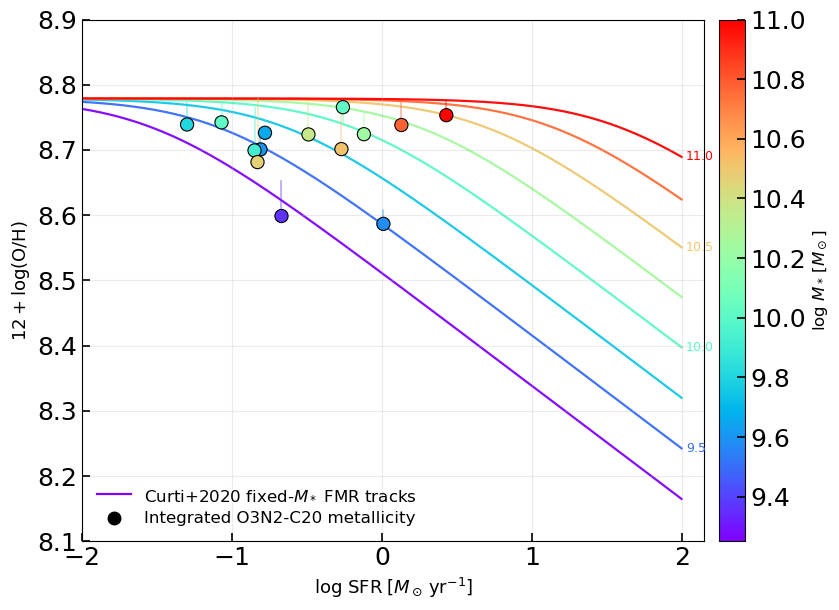

In [5]:
# ================================================================
# 2D Curti+2020 FMR projection:
# integrated SFR vs integrated O/H
# galaxies color-coded by stellar mass
# + fixed-M* Curti+2020 FMR tracks
# ================================================================

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import re
from matplotlib.colors import Normalize
from matplotlib.lines import Line2D

# ------------------------------------------------
# Local integrated-property loaders (cell runs standalone)
# ------------------------------------------------
VILLANUEVA_TABLE_PATH = Path("Villanueva2022Table1.txt")
LEROY_TABLE_PATH = Path("Leroy2021Table4.txt")


def normalize_galaxy_name(name):
    return re.sub(r"\s+", "", name).upper()


def parse_float(token):
    token = token.strip()
    if token == "":
        return None
    try:
        return float(token)
    except ValueError:
        return None


def load_villanueva2022_stellar_mass(table_path):
    """Load logM* from Villanueva+2022 table if available."""
    logmstar = {}
    if not table_path.exists():
        return logmstar

    with open(table_path, "r") as f:
        for raw_line in f:
            line = raw_line.strip()
            if not re.match(r"^(IC|NGC)\s+\d+", line):
                continue

            cols = [c.strip() for c in re.split(r"\t+", line)]
            if len(cols) < 4:
                continue

            name = normalize_galaxy_name(cols[0])
            m = re.search(r"([-+]?\d*\.?\d+)\s*\+or-\s*([-+]?\d*\.?\d+)", cols[3])
            if m is None:
                continue

            logmstar[name] = float(m.group(1))

    return logmstar


def load_leroy2021_properties(table_path):
    """Load logM* and logSFR from Leroy+2021 table if available."""
    logmstar = {}
    logsfr = {}
    if not table_path.exists():
        return logmstar, logsfr

    with open(table_path, "r") as f:
        for raw_line in f:
            if not raw_line[:7].strip().isdigit():
                continue

            ngc = raw_line[8:17].strip()
            ic = raw_line[29:36].strip()
            if ngc:
                name = normalize_galaxy_name(ngc)
            elif ic:
                name = normalize_galaxy_name(ic)
            else:
                continue

            val_logmstar = parse_float(raw_line[48:53])
            if val_logmstar is not None:
                logmstar[name] = val_logmstar

            val_logsfr = parse_float(raw_line[73:78])
            if val_logsfr is not None:
                logsfr[name] = val_logsfr

    return logmstar, logsfr


def extract_total_sfr_from_log(galaxy_name):
    """Extract fallback log10(SFR/Msun yr^-1) from local sfr_logs/<gal>.log."""
    log_file = Path(f"sfr_logs/{galaxy_name}.log")
    if not log_file.exists():
        return None

    try:
        with open(log_file, "r") as f:
            content = f.read()
        pattern = r"Total Halpha SFR from SF region:.*?in log10 scale:\s*([\d.-]+)"
        match = re.search(pattern, content)
        return float(match.group(1)) if match else None
    except Exception as e:
        print(f"Error reading fallback SFR log for {galaxy_name}: {e}")
        return None


def extract_total_stellar_mass_from_log(galaxy_name):
    """Extract fallback log10(M*/Msun) from local mass_logs/<gal>.log."""
    log_file = Path(f"mass_logs/{galaxy_name}.log")
    if not log_file.exists():
        return None

    try:
        with open(log_file, "r") as f:
            content = f.read()
        pattern = r"Total stellar mass \(R\)\s*:\s*([\d.-]+)"
        match = re.search(pattern, content)
        return float(match.group(1)) if match else None
    except Exception as e:
        print(f"Error reading fallback mass log for {galaxy_name}: {e}")
        return None


VILLANUEVA_LOGMSTAR = load_villanueva2022_stellar_mass(VILLANUEVA_TABLE_PATH)
LEROY_LOGMSTAR, LEROY_LOGSFR = load_leroy2021_properties(LEROY_TABLE_PATH)


def get_integrated_stellar_mass(galaxy_name):
    """Return log10(M*/Msun): Villanueva+2022 -> Leroy+2021 -> local mass log."""
    val = VILLANUEVA_LOGMSTAR.get(galaxy_name)
    if val is not None:
        return val
    val = LEROY_LOGMSTAR.get(galaxy_name)
    if val is not None:
        return val
    return extract_total_stellar_mass_from_log(galaxy_name)


def get_integrated_sfr(galaxy_name):
    """Return log10(SFR/Msun yr^-1): Leroy+2021 first, then local log fallback."""
    val = LEROY_LOGSFR.get(galaxy_name)
    if val is not None:
        return val
    return extract_total_sfr_from_log(galaxy_name)


# ------------------------------------------------
# Metallicity extractor
# ------------------------------------------------
def extract_total_o3n2_c20_total_metallicity(galaxy_name):
    """
    Extract total O3N2-C20 metallicity from:
    sfr_logs/{galaxy}.log

    Expected line:
    [O/H] O3N2-C20: Total metallicity in total region: ...
    """
    log_file = Path(f"sfr_logs/{galaxy_name}.log")
    if not log_file.exists():
        return None

    try:
        content = log_file.read_text()
        pattern = r"\[O/H\] O3N2-C20: Total metallicity in total region:\s*([+-]?(?:\d+\.?\d*|\.\d+|nan))"
        match = re.search(pattern, content)
        if not match:
            return None

        value = float(match.group(1))
        return value if np.isfinite(value) else None

    except Exception as e:
        print(f"Error reading metallicity log for {galaxy_name}: {e}")
        return None


# ------------------------------------------------
# Target galaxies
# ------------------------------------------------
GALAXIES = [
    "IC3392",
    "NGC4064",
    "NGC4192",
    "NGC4293",
    "NGC4298",
    "NGC4330",
    "NGC4383",
    "NGC4396",
    "NGC4419",
    "NGC4457",
    "NGC4501",
    "NGC4522",
    "NGC4694",
    "NGC4698",
]


# ------------------------------------------------
# Curti+2020 total-SFR FMR parameters
# ------------------------------------------------
CURTI_Z0 = 8.779
CURTI_M0 = 10.11
CURTI_M1 = 0.56
CURTI_GAMMA = 0.31
CURTI_BETA = 2.1


def curti2020_fmr_total_sfr(
    logMstar,
    logSFR,
    Z0=CURTI_Z0,
    m0=CURTI_M0,
    m1=CURTI_M1,
    gamma=CURTI_GAMMA,
    beta=CURTI_BETA,
):
    """
    Curti+2020 integrated FMR parameterization (total SFR version).

    Returns predicted 12 + log(O/H) for given:
        logMstar = log10(M*/Msun)
        logSFR   = log10(SFR / (Msun/yr))
    """
    logMstar = np.asarray(logMstar, dtype=float)
    logSFR = np.asarray(logSFR, dtype=float)

    logM0_sfr = m0 + m1 * logSFR
    term = 10.0 ** (-beta * (logMstar - logM0_sfr))
    return Z0 - (gamma / beta) * np.log10(1.0 + term)


# ------------------------------------------------
# Gather galaxy data
# ------------------------------------------------
rows = []
for gal in GALAXIES:
    logM = get_integrated_stellar_mass(gal)
    logSFR = get_integrated_sfr(gal)
    Z_obs = extract_total_o3n2_c20_total_metallicity(gal)

    if logM is None or logSFR is None or Z_obs is None:
        print(f"Skipping {gal}: missing logM, logSFR, or Z_obs")
        continue

    Z_pred = curti2020_fmr_total_sfr(logM, logSFR)

    rows.append(
        {
            "gal": gal,
            "logM": float(logM),
            "logSFR": float(logSFR),
            "Z_obs": float(Z_obs),
            "Z_pred": float(Z_pred),
            "deltaZ": float(Z_obs - Z_pred),
        }
    )

if len(rows) == 0:
    raise RuntimeError("No valid galaxy entries found.")

gal_names = np.array([r["gal"] for r in rows])
logM_arr = np.array([r["logM"] for r in rows])
logSFR_arr = np.array([r["logSFR"] for r in rows])
Z_obs_arr = np.array([r["Z_obs"] for r in rows])
Z_pred_arr = np.array([r["Z_pred"] for r in rows])
delta_arr = np.array([r["deltaZ"] for r in rows])

print("Galaxy     logM*    logSFR    Z_obs    Z_pred   Delta(obs-pred)")
for r in rows:
    print(
        f"{r['gal']:8s}  {r['logM']:6.3f}   {r['logSFR']:7.3f}   "
        f"{r['Z_obs']:6.3f}   {r['Z_pred']:6.3f}    {r['deltaZ']:+7.3f}"
    )

print()
print(f"N              = {len(rows)}")
print(f"Mean delta_Z   = {np.mean(delta_arr):+.3f} dex")
print(f"Median delta_Z = {np.median(delta_arr):+.3f} dex")
print(f"RMS delta_Z    = {np.sqrt(np.mean(delta_arr**2)):.3f} dex")


# ------------------------------------------------
# Plot ranges
# ------------------------------------------------
x_min = min(-2.0, np.floor(logSFR_arr.min() * 10) / 10 - 0.2)
x_max = max(2.0, np.ceil(logSFR_arr.max() * 10) / 10 + 0.2)

# Use a slightly wider metallicity range, similar to Curti-style plots
y_min = min(8.10, np.floor(Z_obs_arr.min() * 100) / 100 - 0.03)
y_max = max(8.90, np.ceil(Z_obs_arr.max() * 100) / 100 + 0.03)

# Mass range for fixed-M* tracks
m_min = np.floor(logM_arr.min() * 4) / 4
m_max = np.ceil(logM_arr.max() * 4) / 4

# Choose a sequence of fixed-mass tracks
mass_tracks = np.arange(m_min, m_max + 0.001, 0.25)

# Grid in SFR
sfr_grid = np.linspace(x_min, x_max, 400)

# Colormap for stellar mass
cmap = plt.get_cmap("rainbow")
norm = Normalize(vmin=m_min, vmax=m_max)


# ------------------------------------------------
# Plot
# ------------------------------------------------
fig, ax = plt.subplots(figsize=(8.6, 6.2))

# Fixed-M* Curti+2020 tracks
for i, logM_fixed in enumerate(mass_tracks):
    z_track = curti2020_fmr_total_sfr(logM_fixed, sfr_grid)
    ax.plot(
        sfr_grid,
        z_track,
        color=cmap(norm(logM_fixed)),
        lw=1.6,
        alpha=0.95,
        zorder=1,
        label=r"Curti+2020 fixed-$M_*$ FMR tracks" if i == 0 else None,
    )

    # Optional label at right-hand side for selected tracks
    if np.isclose((logM_fixed * 100) % 50, 0, atol=1e-6):
        x_lab = sfr_grid[-1]
        y_lab = z_track[-1]
        if y_min < y_lab < y_max:
            ax.text(
                x_lab + 0.03,
                y_lab,
                f"{logM_fixed:.1f}",
                color=cmap(norm(logM_fixed)),
                fontsize=9,
                va="center",
            )

# Galaxies
sc = ax.scatter(
    logSFR_arr,
    Z_obs_arr,
    c=logM_arr,
    cmap=cmap,
    norm=norm,
    s=90,
    edgecolor="black",
    linewidth=0.8,
    zorder=3,
    label="Integrated O3N2-C20 metallicity",
)

# Optional: faint vertical guide from each point to its own fixed-M* track prediction
for x, zobs, zpred, m in zip(logSFR_arr, Z_obs_arr, Z_pred_arr, logM_arr):
    ax.plot(
        [x, x],
        [zpred, zobs],
        color=cmap(norm(m)),
        lw=1.2,
        alpha=0.45,
        zorder=2,
    )

# Optional: annotate galaxy names
# for g, x, y in zip(gal_names, logSFR_arr, Z_obs_arr):
#     ax.text(x + 0.03, y + 0.004, g, fontsize=8)

ax.set_xlabel(r'$\log\,\mathrm{SFR}\;[M_\odot\,\mathrm{yr}^{-1}]$', fontsize=13)
ax.set_ylabel(r'$12 + \log(\mathrm{O/H})$', fontsize=13)

ax.set_xlim(x_min, x_max + 0.15)
ax.set_ylim(y_min, y_max)

legend_handles = [
    Line2D(
        [0], [0],
        color=cmap(norm(mass_tracks[0])),
        lw=1.6,
        label=r"Curti+2020 fixed-$M_*$ FMR tracks",
    ),
    Line2D(
        [0], [0],
        marker="o",
        linestyle="None",
        markersize=9,
        markerfacecolor="black",
        markeredgecolor="black",
        color="none",
        label="Integrated O3N2-C20 metallicity",
    ),
]
ax.legend(handles=legend_handles, loc="lower left", frameon=False, fontsize=12)

ax.grid(alpha=0.25)

cbar = fig.colorbar(sc, ax=ax, pad=0.02)
cbar.set_label(r'$\log\,M_*\,[M_\odot]$', fontsize=12)

plt.tight_layout()
plt.show()